<a href="https://colab.research.google.com/github/MalikJunaid553/Linear_regression/blob/main/Linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install pandas scikit-learn matplotlib seaborn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv("Housing.csv")

In [6]:
df.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [7]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [9]:
df.shape

(545, 13)

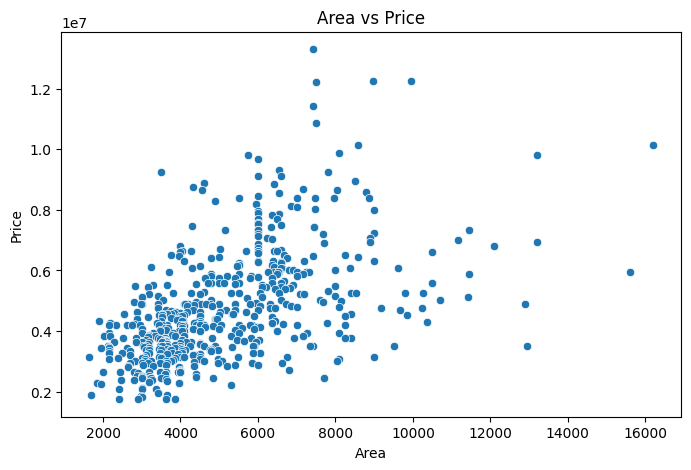

In [10]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="area" , y="price" , data=df)
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

In [11]:
from sklearn.preprocessing import LabelEncoder

# Create separate encoders
le_mainroad = LabelEncoder()
le_guestroom = LabelEncoder()
le_basement = LabelEncoder()
le_hotwaterheating = LabelEncoder()
le_airconditioning = LabelEncoder()
le_prefarea = LabelEncoder()
le_furnishingstatus = LabelEncoder()

# Apply encoding
df["mainroad"] = le_mainroad.fit_transform(df["mainroad"])
df["guestroom"] = le_guestroom.fit_transform(df["guestroom"])
df["basement"] = le_basement.fit_transform(df["basement"])
df["hotwaterheating"] = le_hotwaterheating.fit_transform(df["hotwaterheating"])
df["airconditioning"] = le_airconditioning.fit_transform(df["airconditioning"])
df["prefarea"] = le_prefarea.fit_transform(df["prefarea"])
df["furnishingstatus"] = le_furnishingstatus.fit_transform(df["furnishingstatus"])


In [12]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


In [13]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [15]:
print(df.corr()["price"].sort_values(ascending=False))

price               1.000000
area                0.535997
bathrooms           0.517545
airconditioning     0.452954
stories             0.420712
parking             0.384394
bedrooms            0.366494
prefarea            0.329777
mainroad            0.296898
guestroom           0.255517
basement            0.187057
hotwaterheating     0.093073
furnishingstatus   -0.304721
Name: price, dtype: float64


In [19]:
x = df.drop(["price"], axis=1)

y=df['price']

In [21]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train,y_test=train_test_split(
    x,y ,test_size=0.2, random_state=42
)

In [22]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()

In [23]:
model.fit(x_train , y_train)

LinearRegression()

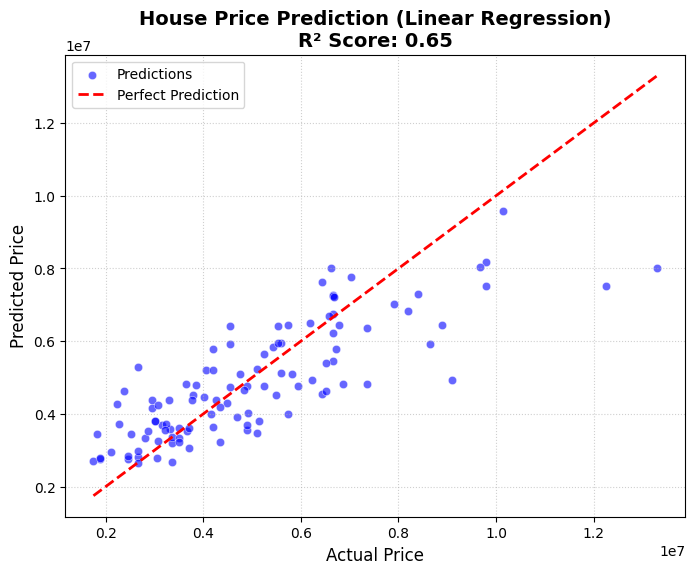

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score


y_pred = model.predict(x_test)


r2 = r2_score(y_test, y_pred)


plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='blue', label='Predictions')


plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2, label='Perfect Prediction')


plt.title(f'House Price Prediction (Linear Regression)\nR² Score: {r2:.2f}', fontsize=14, fontweight='bold')
plt.xlabel('Actual Price', fontsize=12)
plt.ylabel('Predicted Price', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)


plt.show()
